In [1]:
# Calculating mortality for the year 2000 to see if it matches GBD 2021

In [2]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from utils.mortality_utils import att_frac
from utils.mortality_utils import mortality
from utils.utils import land_filter
from utils.utils import autosize_figure

In [3]:
# === Path config ===
BMR_DIR = "/glade/work/awells/air_quality/BMR/"
MASKS_DIR = "/glade/work/awells/air_quality/BMR/masks/country/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
O3_DIR = "/glade/work/awells/air_quality/O3_obs/"

In [4]:
# === Load data ===
bmr_file = "GBD_BMR_Country_Mask_COPD_1990-2009.nc"
bmr_path = os.path.join(BMR_DIR, bmr_file)
BMR = xr.open_dataarray(bmr_path)  # three quantiles

pop_file = "ssp2_coarse_grid_2000.nc"
pop_path = os.path.join(POP_DIR, pop_file)
POP = xr.open_dataarray(pop_path)

o3_file = "Delang_BME_OSDMA8_1990_2017.nc"
o3_path = os.path.join(O3_DIR, o3_file)
o3 = xr.open_dataset(o3_path)["ozone"]
o3_2000 = o3.sel(year=slice("1990", "2009")).mean("year")
o3_2000 = o3_2000.rename({"latitude": "lat", "longitude": "lon"})

In [5]:
# Adjust indices to match (with small tolerance)
# e.g., max 1e-7 km distance
o3_2000 = o3_2000.reindex_like(BMR, method="nearest", tolerance=1e-9,
                               fill_value=0)
POP = POP.reindex_like(BMR, method="nearest", tolerance=1e-9)

# Flag if any nans present (i.e. reindex was out of tolerance distance)
assert not POP.isnull().any()

In [6]:
# === Calculate beta for RR GBD 2021 ===

# Relative risk for 10ppb increase in OSDMA8, GBD 2021
RR_10ppb = 1.074  # [95% CI 1.014 – 1.137]
# equation is: RR = e^(beta*(x-TMREL)) where RR_10ppb = e^(10beta)
beta = np.log(RR_10ppb)/10

# TMREL from GBD 2021
TMREL = 32.4  # [95% CI 29.1 – 35.7]

In [7]:
AF = att_frac(o3_2000, TMREL, beta)
M = mortality(AF, BMR, POP)

In [8]:
global_mortality = M.sum(dim=("lat", "lon"))
mean = global_mortality.sel(quantile="mean").round().values
lower = global_mortality.sel(quantile="lower").round().values
upper = global_mortality.sel(quantile="upper").round().values
print(f"Global mortality is {mean} [{lower}, {upper}]")

Global mortality is 300423.0 [262421.0, 334565.0]


In [9]:
# === Calculate total mortality per country ===
mask_file = "GBD_Country_Masks_0.10_newlabels.nc"
mask_path = os.path.join(MASKS_DIR, mask_file)
masks = xr.open_dataarray(mask_path)

# Create DataArray filled with NaNs
global_M_array = xr.DataArray(
    np.full((len(M.lat), len(M.lon)), np.nan),
    coords={"lat": M.lat.values, "lon": M.lon.values},
    dims=["lat", "lon"]
)

# Loop over countries, add the mortality for each country and apply to array
for i in range(len(masks.country)):
    mask = masks.isel(country=i)
    country = masks.isel(country=i)["country"]
    # mean mortality of country (based on BMR mean)
    M_country = (xr.where(mask == 1,
                          M.sel(quantile="mean"),
                          np.nan)).sum(dim=("lat", "lon"))
    global_M_array = global_M_array.where(mask == 0, M_country)

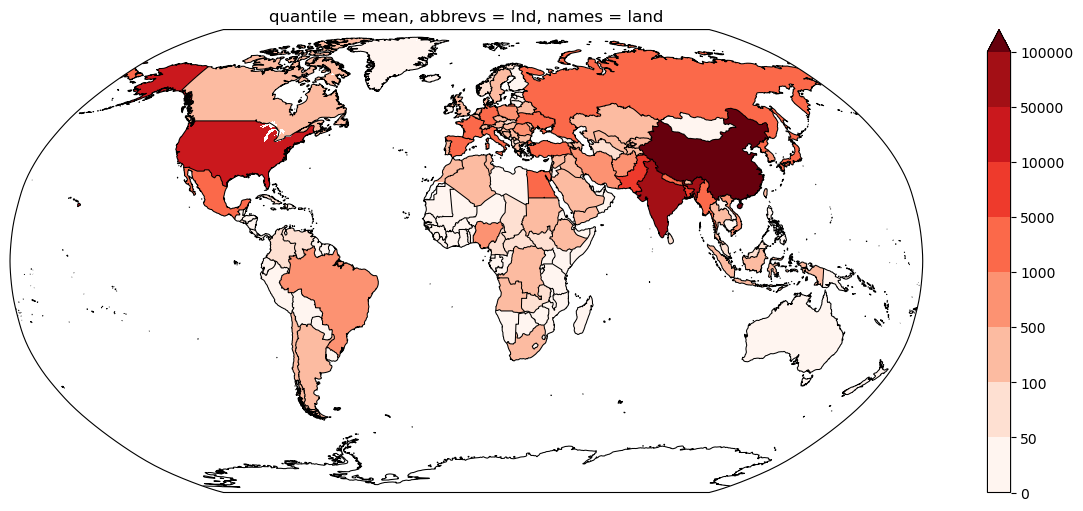

In [10]:
# === Plot country level mortality for year 2000 ===
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=autosize_figure(1, 1, xscale_factor=2))
gs = GridSpec(1, 1)  # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('Reds')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')


# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
land_filter(global_M_array).plot(transform=ccrs.PlateCarree(), cmap=col_map, levels=[0, 50, 100, 500, 1000, 5000, 10000, 50000, 100000])
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)